In [17]:
"""
Fragment 1 — Data Loading with Dynamic Per-Class Augmentation
==============================================================
MobileNetV2 Mould/Fruit Multiclass Classification Pipeline

- Discovers all classes automatically from train folder
- Augments each class up to MAX_TOTAL images then stops
- Saves augmented images to a separate 'augmented' folder
- Builds train and validation generators for model training
"""

import os
import numpy as np
from pathlib import Path
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array,
)

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TRAIN_DIR  = os.path.join(DATA_DIR, "train")
VALID_DIR  = os.path.join(DATA_DIR, "val")
AUG_DIR    = os.path.join(DATA_DIR, "augmented")

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
MAX_TOTAL   = 710          # every class will be augmented up to this number

# ── Augmentation Parameters ───────────────────────────────────────────────────

AUG_PARAMS = dict(
    rotation_range      = 20,
    width_shift_range   = 0.1,
    height_shift_range  = 0.1,
    horizontal_flip     = True,
    vertical_flip       = False,
    zoom_range          = 0.15,
    brightness_range    = [0.75, 1.25],
    shear_range         = 0.1,
    channel_shift_range = 10,
    fill_mode           = "nearest",
)

# ── Step 1: Discover Classes ──────────────────────────────────────────────────

def discover_classes(train_dir: str) -> list:
    classes = sorted([
        d.name for d in Path(train_dir).iterdir()
        if d.is_dir()
    ])
    print("=" * 60)
    print("  Step 1 — Discovered Classes")
    print("=" * 60)
    for i, cls in enumerate(classes, 1):
        src_count = sum(
            1 for f in (Path(train_dir) / cls).iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}
        )
        needed = max(0, MAX_TOTAL - src_count)
        print(f"  {i:>2}. {cls:<22} originals: {src_count:>4}   to generate: {needed:>4}")
    print("=" * 60)
    return classes

# ── Step 2: Augment and Save to Disk ─────────────────────────────────────────

def augment_and_save(train_dir: str, aug_dir: str, classes: list,
                     aug_params: dict) -> None:
    """
    For each class:
      - Copies all originals to the augmented folder
      - Generates augmented images one by one until MAX_TOTAL is reached
      - Stops immediately once the cap is hit
    """
    aug_gen = ImageDataGenerator(**aug_params)

    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

    print("\n" + "=" * 65)
    print("  Step 2 — Augmenting & Saving Images to Disk")
    print("=" * 65)
    print(f"  Source      : {train_dir}")
    print(f"  Destination : {aug_dir}")
    print(f"  Max total   : {MAX_TOTAL} images per class")
    print("=" * 65)

    total_original  = 0
    total_augmented = 0

    for cls in classes:
        src_cls_dir = Path(train_dir) / cls
        dst_cls_dir = Path(aug_dir)   / cls
        dst_cls_dir.mkdir(parents=True, exist_ok=True)

        image_files = [
            f for f in src_cls_dir.iterdir()
            if f.suffix.lower() in IMG_EXTS
            and "_aug_" not in f.stem
        ]

        # ── Copy originals first ──
        for img_path in image_files:
            dst = dst_cls_dir / img_path.name
            if not dst.exists():
                img = load_img(img_path, target_size=IMG_SIZE)
                img.save(dst)

        cls_original  = len(image_files)
        cls_aug_count = 0
        needed        = MAX_TOTAL - cls_original

        if needed <= 0:
            status = "no aug needed"
            print(f"  {cls:<22} | Original: {cls_original:>4}  "
                  f"Augmented: {cls_aug_count:>4}  "
                  f"Total: {cls_original:>4}  ({status})")
            total_original += cls_original
            continue

        # ── Generate augmented images until cap is reached ──
        aug_counter = 0

        while cls_aug_count < needed:
            # Cycle through originals repeatedly if needed
            img_path = image_files[aug_counter % len(image_files)]
            aug_counter += 1

            img = load_img(img_path, target_size=IMG_SIZE)
            arr = np.expand_dims(img_to_array(img), axis=0)

            aug_iter = aug_gen.flow(
                arr,
                batch_size  = 1,
                save_to_dir = str(dst_cls_dir),
                save_prefix = f"aug_{img_path.stem}_{aug_counter:04d}",
                save_format = "jpg",
            )
            next(aug_iter)
            cls_aug_count += 1

        total_original  += cls_original
        total_augmented += cls_aug_count

        print(f"  {cls:<22} | Original: {cls_original:>4}  "
              f"Augmented: {cls_aug_count:>4}  "
              f"Total: {cls_original + cls_aug_count:>4}")

    print("\n" + "=" * 65)
    print(f"  {'TOTAL':<22} | Original: {total_original:>4}  "
          f"Augmented: {total_augmented:>4}  "
          f"Total: {total_original + total_augmented:>4}")
    print("=" * 65)
    print(f"\n  ✓ Augmented images saved to: {aug_dir}\n")

# ── Step 3: Build Generators ──────────────────────────────────────────────────

def build_generators(aug_dir: str, valid_dir: str):
    """
    Builds train generator from augmented folder (rescale only)
    and validation generator from val folder (rescale only).
    No augmentation applied here — images already saved to disk.
    """

    train_datagen = ImageDataGenerator(rescale=1.0 / 255)
    train_generator = train_datagen.flow_from_directory(
        aug_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = True,
    )

    valid_datagen = ImageDataGenerator(rescale=1.0 / 255)
    valid_generator = valid_datagen.flow_from_directory(
        valid_dir,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False,
    )

    print("\n" + "=" * 60)
    print("  Step 3 — Data Generators Ready")
    print("=" * 60)
    print(f"  Train samples : {train_generator.samples}")
    print(f"  Valid samples : {valid_generator.samples}")
    print(f"  Classes       : {list(train_generator.class_indices.keys())}")
    print(f"  Image size    : {IMG_SIZE}")
    print(f"  Batch size    : {BATCH_SIZE}")
    print("=" * 60)

    return train_generator, valid_generator

# ── Run Fragment 1 ────────────────────────────────────────────────────────────

classes = discover_classes(TRAIN_DIR)
augment_and_save(TRAIN_DIR, AUG_DIR, classes, AUG_PARAMS)
train_generator, valid_generator = build_generators(AUG_DIR, VALID_DIR)

print("\n  ✓ Fragment 1 complete. train_generator and valid_generator are ready.")
print("     Proceed to Fragment 1b — Optuna Hyperparameter Tuning.\n")

  Step 1 — Discovered Classes
   1. Blackberry             originals:  117   to generate:  593
   2. Blueberry              originals:  117   to generate:  593
   3. Carrots                originals:  235   to generate:  475
   4. Cheese                 originals:  142   to generate:  568
   5. Cream Cheese           originals:  233   to generate:  477
   6. Mixed Bread            originals:  168   to generate:  542
   7. Onion                  originals:  479   to generate:  231
   8. Orange                 originals:  329   to generate:  381
   9. Raspberry              originals:  117   to generate:  593
  10. Toast                  originals:  478   to generate:  232
  11. Tomatoes               originals:  604   to generate:  106

  Step 2 — Augmenting & Saving Images to Disk
  Source      : D:\Mold Studies\Mould Studies Multiclass\train
  Destination : D:\Mold Studies\Mould Studies Multiclass\augmented
  Max total   : 710 images per class
  Blackberry             | Original:  117

KeyboardInterrupt: 

In [ ]:
"""
Fragment 2 — MobileNetV2 Model Building with Transfer Learning
==============================================================
- Loads MobileNetV2 with ImageNet weights
- Accepts learning rate, dropout rate and unfreeze depth as inputs
- Freezes base layers except last N unfrozen layers
- Adds custom classification head
- Compiled and ready to receive Optuna parameters in Fragment 1b
"""

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.optimizers import Adam

# ── Configuration ─────────────────────────────────────────────────────────────

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
NUM_CLASSES = len(train_generator.class_indices)
CLASS_NAMES = list(train_generator.class_indices.keys())

# ── Default values — will be overridden by Optuna in Fragment 1b ──────────────

DEFAULT_LEARNING_RATE   = 1e-4
DEFAULT_DROPOUT_RATE    = 0.3
DEFAULT_UNFREEZE_LAYERS = 0
EPOCHS                  = 25

# ── Step 1: Model Builder ─────────────────────────────────────────────────────

def build_mobilenet(learning_rate, dropout_rate, unfreeze_layers, epochs=EPOCHS):
    """
    Builds and compiles MobileNetV2 with a custom classification head.

    Parameters
    ----------
    learning_rate   : float — Adam optimizer learning rate
                              Optuna search range : 1e-5 to 1e-2 (log scale)

    dropout_rate    : float — dropout applied in classification head
                              Optuna search range : 0.2 to 0.6

    unfreeze_layers : int   — number of base layers unfrozen from the top
                              Optuna search range : 0 to 30
                              0  = fully frozen, feature extraction only
                              10 = fine-tune last 10 base layers
                              30 = fine-tune last 30 base layers

    epochs          : int   — number of training epochs
                              default : 30
    """

    # ── Load MobileNetV2 with ImageNet weights ──
    base_model = MobileNetV2(
        input_shape = IMG_SHAPE,
        include_top = False,
        weights     = "imagenet"
    )

    # ── Freeze all base layers first ──
    base_model.trainable = False

    # ── Unfreeze last N layers (skip BatchNorm layers) ──
    if unfreeze_layers > 0:
        for layer in base_model.layers[-unfreeze_layers:]:
            if not isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = True

    # ── Classification head ──
    x      = base_model.output
    x      = GlobalAveragePooling2D(name="global_avg_pool")(x)
    x      = BatchNormalization(name="head_batch_norm")(x)
    x      = Dense(256, activation="relu", name="dense_256")(x)
    x      = Dropout(dropout_rate, name="dropout_1")(x)
    x      = Dense(128, activation="relu", name="dense_128")(x)
    x      = Dropout(dropout_rate / 2, name="dropout_2")(x)
    output = Dense(NUM_CLASSES, activation="softmax", name="output")(x)

    # ── Assemble model ──
    model = Model(inputs=base_model.input, outputs=output)

    # ── Compile ──
    model.compile(
        optimizer = Adam(learning_rate=learning_rate),
        loss      = "categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    return model

# ── Step 2: Build default model and print summary ─────────────────────────────

model = build_mobilenet(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS
)

# ── Count parameters ──
total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in model.non_trainable_weights)

# ── Count unfrozen base layers ──
base_layers      = [l for l in model.layers if "mobilenetv2" in l.name or
                    hasattr(l, "_is_layer")]
unfrozen_base    = sum(1 for l in model.layers if l.trainable
                       and l.name not in
                       ["global_avg_pool", "head_batch_norm",
                        "dense_256", "dropout_1",
                        "dense_128", "dropout_2", "output"])

print("=" * 60)
print("  Fragment 2 — MobileNetV2 Transfer Learning")
print("=" * 60)

print("\n  ── Inputs ──────────────────────────────────────────")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")

print("\n  ── Base Model ──────────────────────────────────────")
print(f"  Architecture     : MobileNetV2")
print(f"  Weights          : ImageNet ✓")
print(f"  Input shape      : {IMG_SHAPE}")
print(f"  Unfrozen layers  : {unfrozen_base}")

print("\n  ── Classification Head ─────────────────────────────")
print(f"  GlobalAveragePooling2D")
print(f"  BatchNormalization")
print(f"  Dense(256, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE})")
print(f"  Dense(128, relu)")
print(f"  Dropout({DEFAULT_DROPOUT_RATE / 2})")
print(f"  Dense({NUM_CLASSES}, softmax)  ← {NUM_CLASSES} classes")
print(f"  Classes          : {CLASS_NAMES}")

print("\n  ── Parameters ──────────────────────────────────────")
print(f"  Total params     : {total_params:,}")
print(f"  Trainable        : {trainable_params:,}")
print(f"  Frozen           : {frozen_params:,}")

print("\n  ── Optuna Search Space (Fragment 1b) ───────────────")
print(f"  learning_rate    : 1e-5  → 1e-2  (log scale)")
print(f"  dropout_rate     : 0.2   → 0.6")
print(f"  unfreeze_layers  : 0     → 30")
print(f"  epochs           : {EPOCHS}")
print("=" * 60)

print("\n  ✓ Fragment 2 complete. build_mobilenet() is ready.")
print("     Proceed to Fragment 1b — Optuna Hyperparameter Tuning.\n")

  Fragment 2 — MobileNetV2 Transfer Learning

  ── Inputs ──────────────────────────────────────────
  Learning rate    : 0.0001
  Dropout rate     : 0.3
  Unfreeze layers  : 0

  ── Base Model ──────────────────────────────────────
  Architecture     : MobileNetV2
  Weights          : ImageNet ✓
  Input shape      : (224, 224, 3)
  Unfrozen layers  : 0

  ── Classification Head ─────────────────────────────
  GlobalAveragePooling2D
  BatchNormalization
  Dense(256, relu)
  Dropout(0.3)
  Dense(128, relu)
  Dropout(0.15)
  Dense(11, softmax)  ← 11 classes
  Classes          : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']

  ── Parameters ──────────────────────────────────────
  Total params     : 2,625,355
  Trainable        : 364,811
  Frozen           : 2,260,544

  ── Optuna Search Space (Fragment 1b) ───────────────
  learning_rate    : 1e-5  → 1e-2  (log scale)
  dropout_rate     : 0.2   → 0.6
 

In [ ]:
"""
Fragment 3 — Callbacks & Model Training
========================================
MobileNetV2 Mould/Fruit Multiclass Classification Pipeline

- Defines all callbacks:
    * ModelCheckpoint    — saves best model based on val_accuracy
    * EarlyStopping      — stops training if no improvement
    * ReduceLROnPlateau  — reduces LR when val_loss stalls
    * CSVLogger          — logs all metrics per epoch to CSV
- Trains model using best parameters from Optuna (Fragment 1b)
- Validates on val set only
- Stores history for Fragment 4 evaluation:
    * Accuracy, Loss curves
    * Sensitivity, Specificity, Recall, F1, AUC/ROC
    * Confusion Matrix
"""

import os
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR     = r"D:\Mold Studies\Models"
MODEL_NAME   = "mobilenetv2_mould_best.keras"
CSV_LOG_NAME = "mobilenetv2_training_log.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
CSV_PATH   = os.path.join(SAVE_DIR, CSV_LOG_NAME)

# ── Callback Parameters ───────────────────────────────────────────────────────

# EarlyStopping
ES_PATIENCE   = 10       # stop after N epochs with no val_accuracy improvement
ES_MIN_DELTA  = 1e-4     # minimum change to count as improvement

# ReduceLROnPlateau
RLROP_FACTOR    = 0.5    # multiply LR by this on plateau
RLROP_PATIENCE  = 5      # epochs with no improvement before reducing LR
RLROP_MIN_LR    = 1e-7   # LR floor
RLROP_MIN_DELTA = 1e-4   # minimum change to count as improvement

# ── Step 1: Define Callbacks ──────────────────────────────────────────────────

checkpoint = ModelCheckpoint(
    filepath          = MODEL_PATH,
    monitor           = "val_accuracy",
    save_best_only    = True,
    save_weights_only = False,
    mode              = "max",
    verbose           = 1,
)

early_stopping = EarlyStopping(
    monitor              = "val_accuracy",
    patience             = ES_PATIENCE,
    min_delta            = ES_MIN_DELTA,
    mode                 = "max",
    restore_best_weights = True,   # rolls back to best epoch on stop
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor   = "val_loss",
    factor    = RLROP_FACTOR,
    patience  = RLROP_PATIENCE,
    min_lr    = RLROP_MIN_LR,
    min_delta = RLROP_MIN_DELTA,
    mode      = "min",
    verbose   = 1,
)

csv_logger = CSVLogger(
    filename  = CSV_PATH,
    separator = ",",
    append    = False,
)

callbacks = [checkpoint, early_stopping, reduce_lr, csv_logger]

print("=" * 60)
print("  Step 1 — Callbacks Configured")
print("=" * 60)
print(f"  ModelCheckpoint  : best val_accuracy → {MODEL_PATH}")
print(f"  EarlyStopping    : patience={ES_PATIENCE} epochs, "
      f"restores best weights")
print(f"  ReduceLROnPlateau: factor={RLROP_FACTOR} after "
      f"{RLROP_PATIENCE} stale epochs, floor={RLROP_MIN_LR}")
print(f"  CSVLogger        : epoch log → {CSV_PATH}")
print("=" * 60)

# ── Step 2: Confirm Optuna Parameters Received ────────────────────────────────

print("\n" + "=" * 60)
print("  Step 2 — Training Configuration")
print("=" * 60)
print(f"  Train samples    : {train_generator.samples}")
print(f"  Valid samples    : {valid_generator.samples}")
print(f"  Classes          : {NUM_CLASSES}")
print(f"  Epochs           : {EPOCHS}")
print(f"  Batch size       : {BATCH_SIZE}")
print(f"  Learning rate    : {DEFAULT_LEARNING_RATE:.6f}")
print(f"  Dropout rate     : {DEFAULT_DROPOUT_RATE:.4f}")
print(f"  Unfreeze layers  : {DEFAULT_UNFREEZE_LAYERS}")
print("=" * 60 + "\n")

# ── Step 3: Build Final Model with Best Optuna Parameters ─────────────────────

model = build_mobilenet(
    learning_rate   = DEFAULT_LEARNING_RATE,
    dropout_rate    = DEFAULT_DROPOUT_RATE,
    unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
    epochs          = EPOCHS,
)

# ── Step 4: Train ─────────────────────────────────────────────────────────────

history = model.fit(
    train_generator,
    epochs           = EPOCHS,
    validation_data  = valid_generator,
    callbacks        = callbacks,
    steps_per_epoch  = train_generator.samples  // BATCH_SIZE,
    validation_steps = valid_generator.samples  // BATCH_SIZE,
)

# ── Step 5: Training Summary ──────────────────────────────────────────────────

best_val_acc  = max(history.history["val_accuracy"])
best_val_loss = min(history.history["val_loss"])
epochs_run    = len(history.history["accuracy"])
best_epoch    = history.history["val_accuracy"].index(best_val_acc) + 1

print("\n" + "=" * 60)
print("  Step 5 — Training Complete")
print("=" * 60)
print(f"  Epochs run       : {epochs_run} / {EPOCHS}")
print(f"  Best epoch       : {best_epoch}")
print(f"  Best val accuracy: {best_val_acc:.4f}  ({best_val_acc * 100:.2f}%)")
print(f"  Best val loss    : {best_val_loss:.4f}")
print(f"  Best model saved : {MODEL_PATH}")
print(f"  Training log     : {CSV_PATH}")
print("=" * 60)

print("\n  ── Metrics available for Fragment 4 evaluation ─────")
print("  ✓ Accuracy        — per epoch (train + val)")
print("  ✓ Loss            — per epoch (train + val)")
print("  ✓ Sensitivity     — will be computed from confusion matrix")
print("  ✓ Specificity     — will be computed from confusion matrix")
print("  ✓ Recall          — will be computed from confusion matrix")
print("  ✓ F1 Score        — will be computed from confusion matrix")
print("  ✓ AUC / ROC       — will be computed per class (one-vs-rest)")
print("  ✓ Confusion Matrix — full 11-class matrix")
print("=" * 60)

print("\n  ✓ Fragment 3 complete. history and model are ready.")
print("     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Step 1 — Callbacks Configured
  ModelCheckpoint  : best val_accuracy → D:\Mold Studies\Models\mobilenetv2_mould_best.keras
  EarlyStopping    : patience=10 epochs, restores best weights
  ReduceLROnPlateau: factor=0.5 after 5 stale epochs, floor=1e-07
  CSVLogger        : epoch log → D:\Mold Studies\Models\mobilenetv2_training_log.csv

  Step 2 — Training Configuration
  Train samples    : 7810
  Valid samples    : 644
  Classes          : 11
  Epochs           : 25
  Batch size       : 32
  Learning rate    : 0.000100
  Dropout rate     : 0.3000
  Unfreeze layers  : 0

Epoch 1/25


244/244 [==============================] - ETA: 0s - loss: 0.9230 - accuracy: 0.7277
Epoch 1: val_accuracy improved from -inf to 0.95625, saving model to D:\Mold Studies\Models\mobilenetv2_mould_best.keras
244/244 [==============================] - 93s 374ms/step - loss: 0.9230 - accuracy: 0.7277 - val_loss: 0.2316 - val_accuracy: 0.9563 - lr: 1.0000e-04
Epoch 2/25
244/244 [==============================]

In [ ]:
"""
Fragment 3b — Multi-Run Training (MobileNetV2)
===============================================
MobileNetV2 Mould/Fruit Multiclass Classification Pipeline

Runs 4 additional independent training loops (Runs 2–5).
Run 1 was completed in Fragment 3 and its model is already saved.
Each run starts from fresh ImageNet weights with randomly
reinitialised classification head.

OUTPUT: 5 models saved to disk for statistical analysis
    mobilenetv2_run1_best.keras   (copied from Fragment 3)
    mobilenetv2_run2_best.keras
    mobilenetv2_run3_best.keras
    mobilenetv2_run4_best.keras
    mobilenetv2_run5_best.keras

DATA BOUNDARIES — unchanged from Fragment 3:
    Training   : train_generator  (augmented folder)
    Validation : valid_generator  (val folder)
    Test       : NOT TOUCHED — Fragment 4 only
"""

import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger,
)
from tensorflow.keras.optimizers import Adam

# ── Configuration ─────────────────────────────────────────────────────────────

SAVE_DIR   = r"D:\Mold Studies\Models"
TOTAL_RUNS = 5

os.makedirs(SAVE_DIR, exist_ok=True)

# ── Step 1: Rename Fragment 3 model → Run 1 ──────────────────────────────────

src = os.path.join(SAVE_DIR, "mobilenetv2_mould_best.keras")
dst = os.path.join(SAVE_DIR, "mobilenetv2_run1_best.keras")

if os.path.exists(src) and not os.path.exists(dst):
    shutil.copy2(src, dst)
    print(f"  Copied  : mobilenetv2_mould_best.keras → mobilenetv2_run1_best.keras")
elif os.path.exists(dst):
    print(f"  Already exists : mobilenetv2_run1_best.keras — skipping copy")
else:
    print(f"  WARNING : mobilenetv2_mould_best.keras not found")
    print(f"            Ensure Fragment 3 completed successfully before continuing")

# ── Step 2: Collect Run 1 results from Fragment 3 ────────────────────────────

all_run_results = [
    {
        "run"          : 1,
        "best_val_acc" : best_val_acc,
        "best_val_loss": best_val_loss,
        "best_epoch"   : best_epoch,
        "checkpoint"   : "mobilenetv2_run1_best.keras"
    }
]

print(f"\n  Run 1 loaded from Fragment 3")
print(f"    Best val accuracy : {best_val_acc:.4f}")
print(f"    Best val loss     : {best_val_loss:.4f}")
print(f"    Best epoch        : {best_epoch}")

# ── Step 3: Runs 2–5 ──────────────────────────────────────────────────────────

print(f"\n{'='*60}")
print(f"  MULTI-RUN TRAINING — Runs 2 to {TOTAL_RUNS}")
print(f"  Each run : fresh ImageNet weights, random head init")
print(f"  Epochs   : {EPOCHS}")
print(f"  LR       : {DEFAULT_LEARNING_RATE}")
print(f"  Dropout  : {DEFAULT_DROPOUT_RATE}")
print(f"  Unfreeze : {DEFAULT_UNFREEZE_LAYERS} layers")
print(f"{'='*60}")

for run_idx in range(2, TOTAL_RUNS + 1):

    print(f"\n{'='*60}")
    print(f"  RUN {run_idx} / {TOTAL_RUNS}")
    print(f"{'='*60}\n")

    ckpt_path  = os.path.join(SAVE_DIR, f"mobilenetv2_run{run_idx}_best.keras")
    csv_path   = os.path.join(SAVE_DIR, f"mobilenetv2_run{run_idx}_log.csv")

    # ── Fresh model — new random head, ImageNet backbone ──────────────────────
    run_model = build_mobilenet(
        learning_rate   = DEFAULT_LEARNING_RATE,
        dropout_rate    = DEFAULT_DROPOUT_RATE,
        unfreeze_layers = DEFAULT_UNFREEZE_LAYERS,
        epochs          = EPOCHS,
    )

    # ── Run-specific callbacks ─────────────────────────────────────────────────
    run_callbacks = [
        ModelCheckpoint(
            filepath          = ckpt_path,
            monitor           = "val_accuracy",
            save_best_only    = True,
            save_weights_only = False,
            save_format       = "keras",
            mode              = "max",
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = "val_accuracy",
            patience             = ES_PATIENCE,
            min_delta            = ES_MIN_DELTA,
            mode                 = "max",
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor   = "val_loss",
            factor    = RLROP_FACTOR,
            patience  = RLROP_PATIENCE,
            min_lr    = RLROP_MIN_LR,
            min_delta = RLROP_MIN_DELTA,
            mode      = "min",
            verbose   = 1,
        ),
        CSVLogger(
            filename  = csv_path,
            separator = ",",
            append    = False,
        ),
    ]

    # ── Train ──────────────────────────────────────────────────────────────────
    run_history = run_model.fit(
        train_generator,
        validation_data  = valid_generator,
        epochs           = EPOCHS,
        callbacks        = run_callbacks,
        steps_per_epoch  = train_generator.samples // BATCH_SIZE,
        validation_steps = valid_generator.samples // BATCH_SIZE,
    )

    # ── Extract best metrics ───────────────────────────────────────────────────
    run_best_val_acc  = max(run_history.history["val_accuracy"])
    run_best_val_loss = min(run_history.history["val_loss"])
    run_best_epoch    = run_history.history["val_accuracy"].index(run_best_val_acc) + 1
    run_epochs_run    = len(run_history.history["accuracy"])

    # ── Force save in .keras format ───────────────────────────────────────────
    run_model.save(ckpt_path)

    all_run_results.append({
        "run"          : run_idx,
        "best_val_acc" : run_best_val_acc,
        "best_val_loss": run_best_val_loss,
        "best_epoch"   : run_best_epoch,
        "checkpoint"   : f"mobilenetv2_run{run_idx}_best.keras"
    })

    print(f"\n  Run {run_idx} complete")
    print(f"    Epochs run        : {run_epochs_run} / {EPOCHS}")
    print(f"    Best epoch        : {run_best_epoch}")
    print(f"    Best val accuracy : {run_best_val_acc:.4f}")
    print(f"    Best val loss     : {run_best_val_loss:.4f}")
    print(f"    Saved to          : {ckpt_path}")

# ── Step 4: Summary across all 5 runs ────────────────────────────────────────

val_accs  = [r["best_val_acc"]  for r in all_run_results]
val_losses = [r["best_val_loss"] for r in all_run_results]

print(f"\n{'='*60}")
print(f"  ALL RUNS COMPLETE — Summary")
print(f"{'='*60}")
print(f"  {'Run':<6} {'Val Acc':>10} {'Val Loss':>10} "
      f"{'Best Epoch':>12} {'Checkpoint'}")
print(f"  {'─'*70}")

for r in all_run_results:
    print(f"  {r['run']:<6} {r['best_val_acc']:>10.4f} "
          f"{r['best_val_loss']:>10.4f} {r['best_epoch']:>12} "
          f"{r['checkpoint']}")

best_run = max(all_run_results, key=lambda x: x["best_val_acc"])

print(f"\n  {'─'*60}")
print(f"  Mean val accuracy  : {np.mean(val_accs):.4f}")
print(f"  Std  val accuracy  : {np.std(val_accs):.4f}")
print(f"  Mean val loss      : {np.mean(val_losses):.4f}")
print(f"  Std  val loss      : {np.std(val_losses):.4f}")
print(f"\n  Best single run    : Run {best_run['run']} "
      f"— Val Acc {best_run['best_val_acc']:.4f}")
print(f"{'='*60}")

# ── Step 5: Expose checkpoint list for Fragment 4 ────────────────────────────

ensemble_checkpoints = [
    os.path.join(SAVE_DIR, r["checkpoint"]) for r in all_run_results
]

print(f"\n  ✓ Fragment 3b complete.")
print(f"  ensemble_checkpoints = {ensemble_checkpoints}")
print(f"\n     Proceed to Fragment 4 — Evaluation & Metrics.\n")

  Copied  : mobilenetv2_mould_best.keras → mobilenetv2_run1_best.keras

  Run 1 loaded from Fragment 3
    Best val accuracy : 0.9953
    Best val loss     : 0.0267
    Best epoch        : 23

  MULTI-RUN TRAINING — Runs 2 to 5
  Each run : fresh ImageNet weights, random head init
  Epochs   : 25
  LR       : 0.0001
  Dropout  : 0.3
  Unfreeze : 0 layers

  RUN 2 / 5

Epoch 1/25
244/244 [==============================] - ETA: 0s - loss: 0.8388 - accuracy: 0.7557
Epoch 1: val_accuracy improved from -inf to 0.96250, saving model to D:\Mold Studies\Models\mobilenetv2_run2_best.keras
244/244 [==============================] - 66s 262ms/step - loss: 0.8388 - accuracy: 0.7557 - val_loss: 0.1874 - val_accuracy: 0.9625 - lr: 1.0000e-04
Epoch 2/25
244/244 [==============================] - ETA: 0s - loss: 0.1886 - accuracy: 0.9457
Epoch 2: val_accuracy improved from 0.96250 to 0.98438, saving model to D:\Mold Studies\Models\mobilenetv2_run2_best.keras
244/244 [==============================] - 

Found 658 images belonging to 11 classes.
  Step 1 — Test Generator Ready
  Test samples : 658
  Classes      : ['Blackberry', 'Blueberry', 'Carrots', 'Cheese', 'Cream Cheese', 'Mixed Bread', 'Onion', 'Orange', 'Raspberry', 'Toast', 'Tomatoes']

  Evaluating Run 1 / 5
  Checkpoint : D:\Mold Studies\Models\mobilenetv2_run1_best.keras
21/21 [==============================] - 6s 253ms/step

  Accuracy     : 0.9878
  Precision    : 0.9869
  Recall       : 0.9876
  Specificity  : 0.9988
  F1 Score     : 0.9871
  Mean AUC     : 0.9999


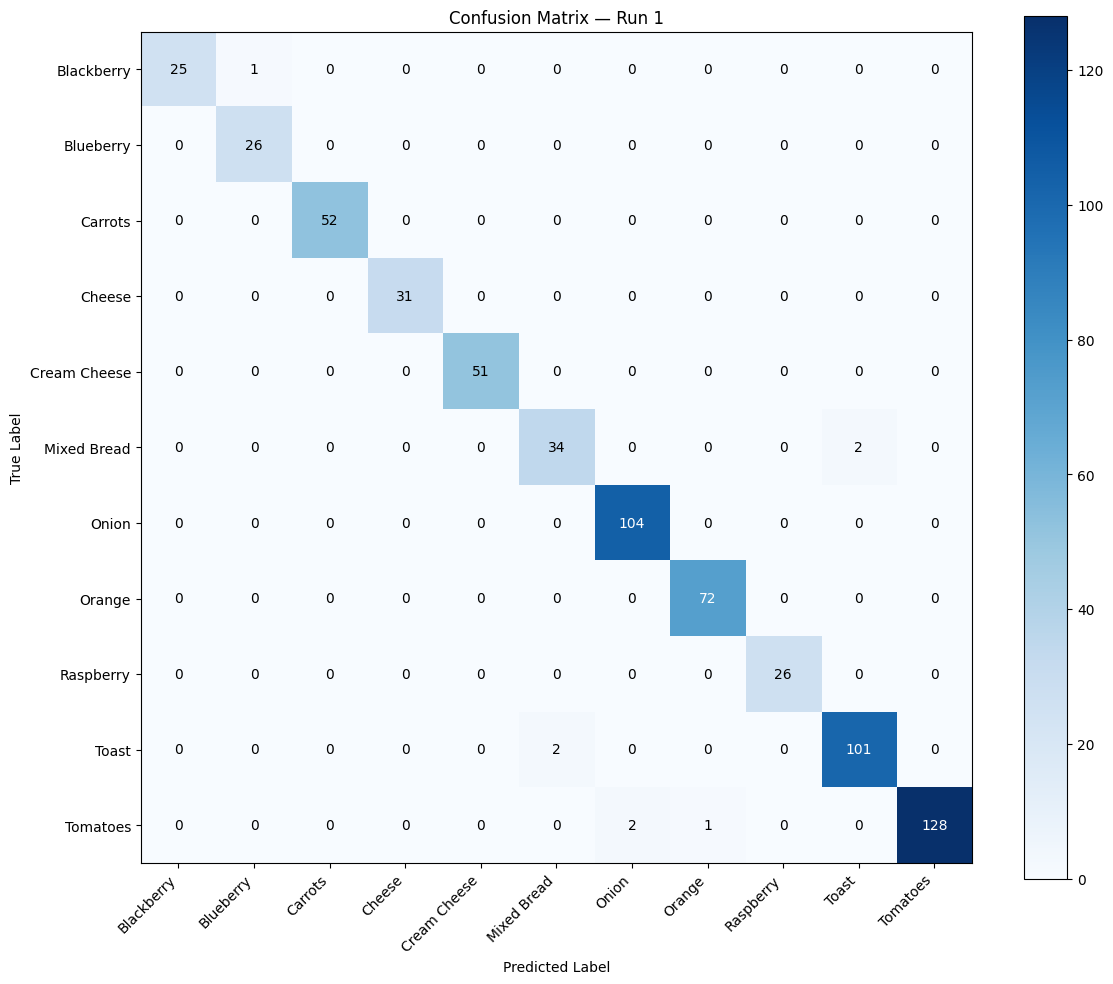

  Saved: D:\Mold Studies\Models\plots\confusion_matrix_run1.png


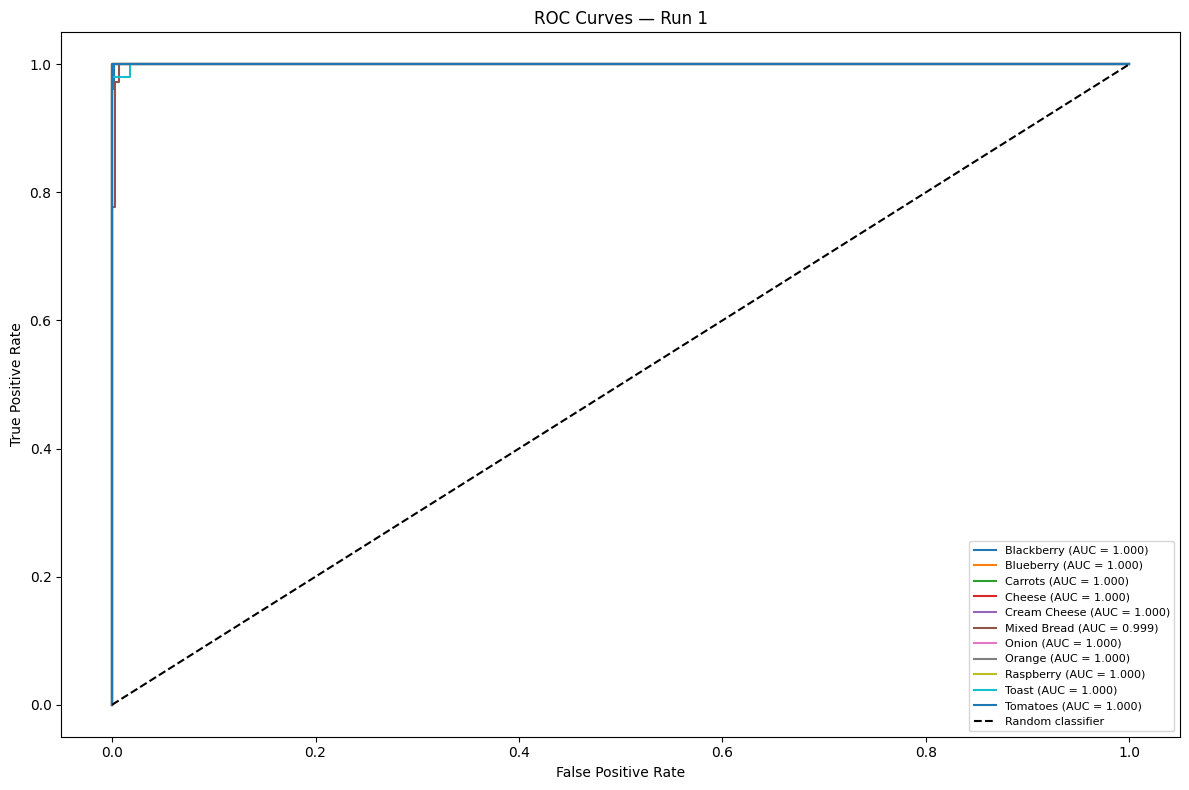

  Saved: D:\Mold Studies\Models\plots\roc_curves_run1.png


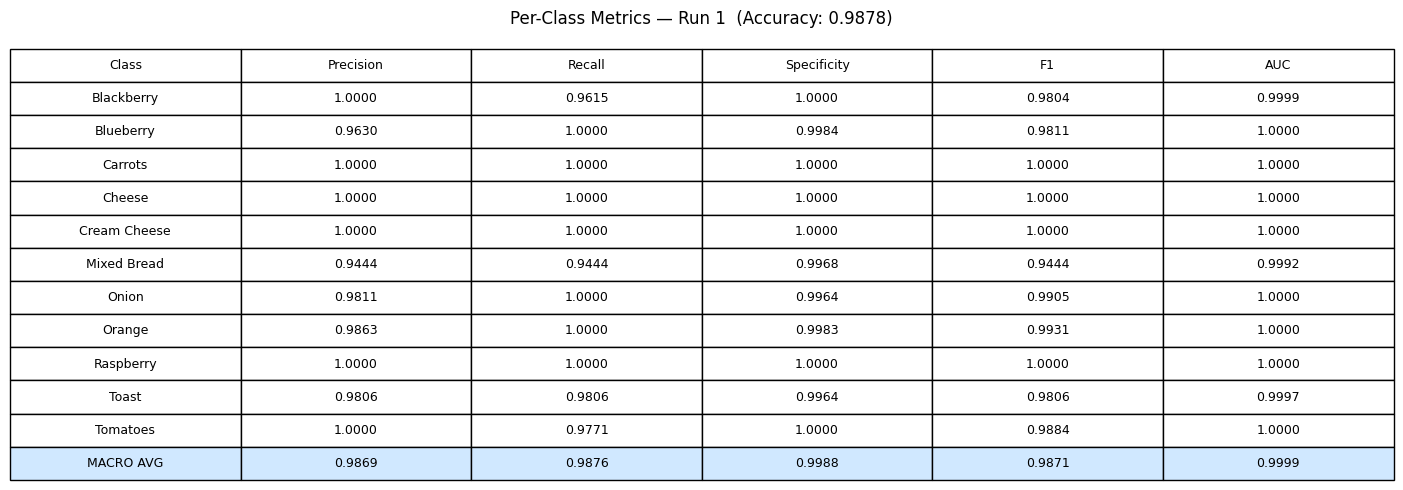

  Saved: D:\Mold Studies\Models\plots\metrics_table_run1.png
  ⚠️  CSV log not found for Run 1: D:\Mold Studies\Models\mobilenetv2_run1_log.csv

  Evaluating Run 2 / 5
  Checkpoint : D:\Mold Studies\Models\mobilenetv2_run2_best.keras
21/21 [==============================] - 3s 101ms/step

  Accuracy     : 0.9833
  Precision    : 0.9817
  Recall       : 0.9843
  Specificity  : 0.9983
  F1 Score     : 0.9828
  Mean AUC     : 0.9998


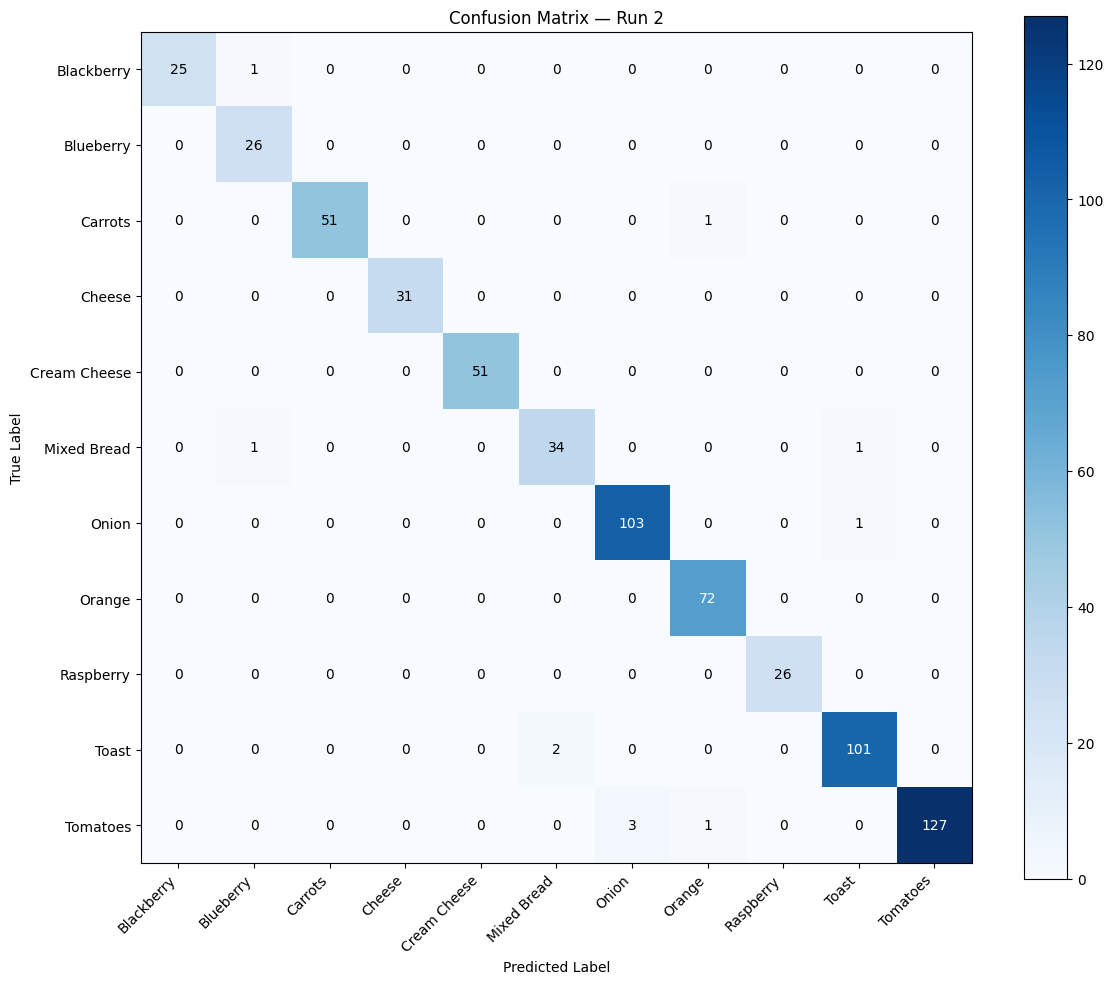

  Saved: D:\Mold Studies\Models\plots\confusion_matrix_run2.png


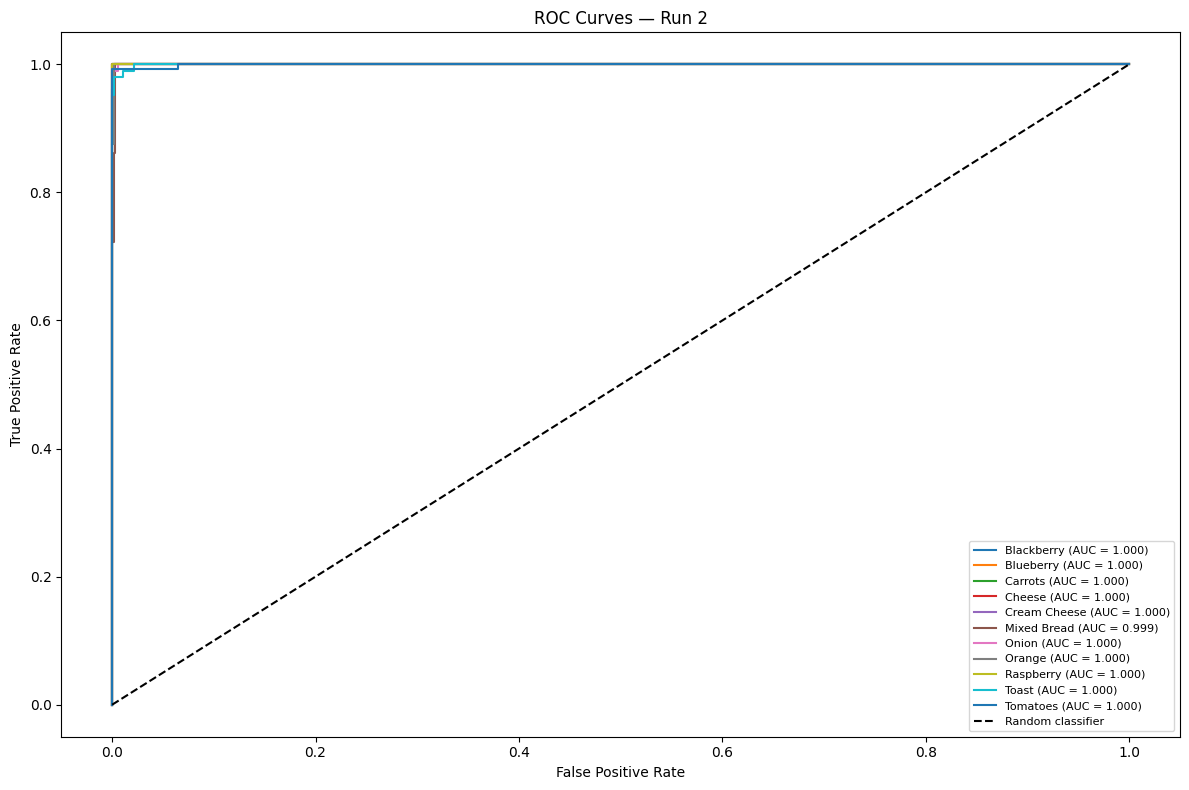

  Saved: D:\Mold Studies\Models\plots\roc_curves_run2.png


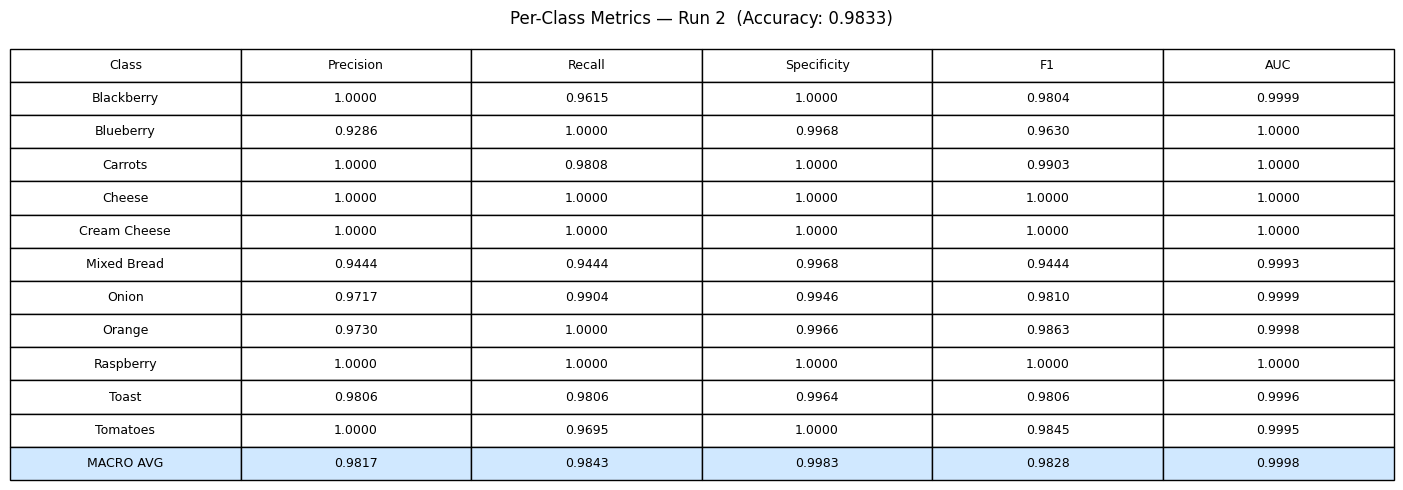

  Saved: D:\Mold Studies\Models\plots\metrics_table_run2.png


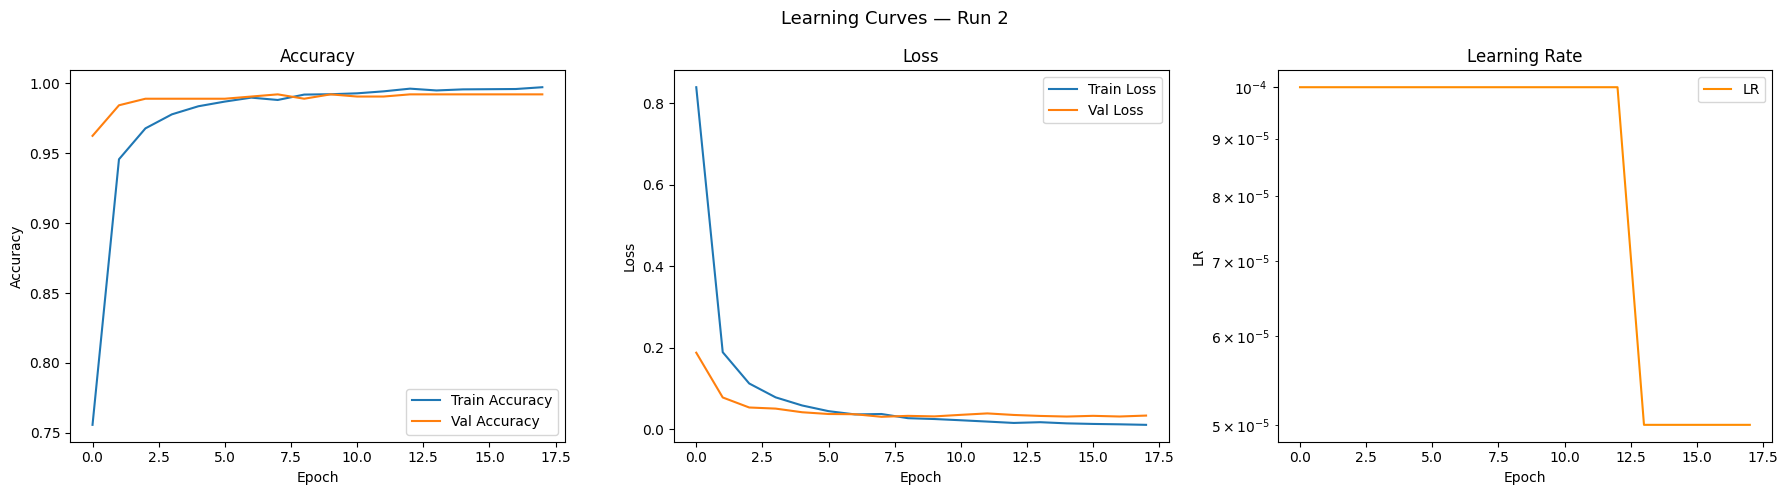

  Saved: D:\Mold Studies\Models\plots\learning_curves_run2.png

  Evaluating Run 3 / 5
  Checkpoint : D:\Mold Studies\Models\mobilenetv2_run3_best.keras
21/21 [==============================] - 3s 102ms/step

  Accuracy     : 0.9878
  Precision    : 0.9844
  Recall       : 0.9866
  Specificity  : 0.9988
  F1 Score     : 0.9854
  Mean AUC     : 0.9999


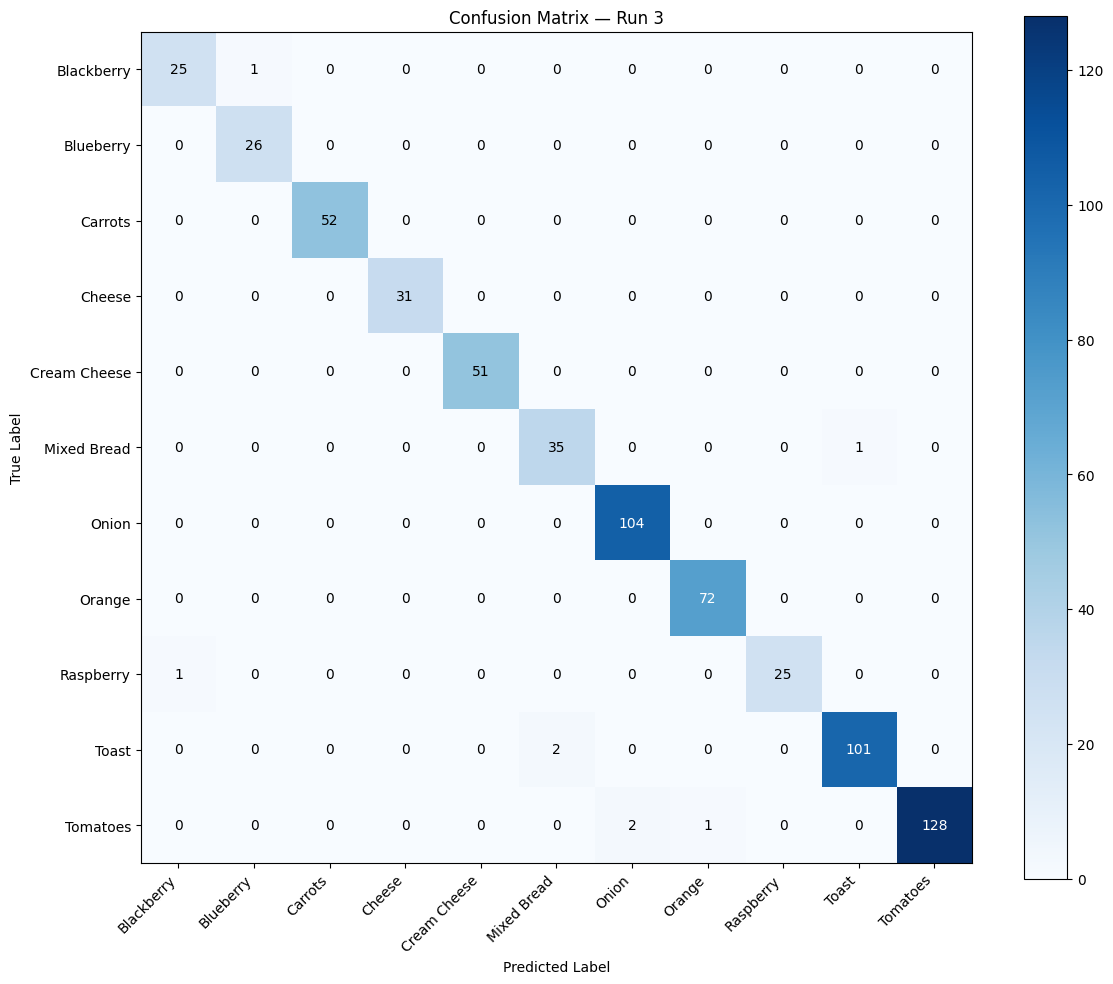

  Saved: D:\Mold Studies\Models\plots\confusion_matrix_run3.png


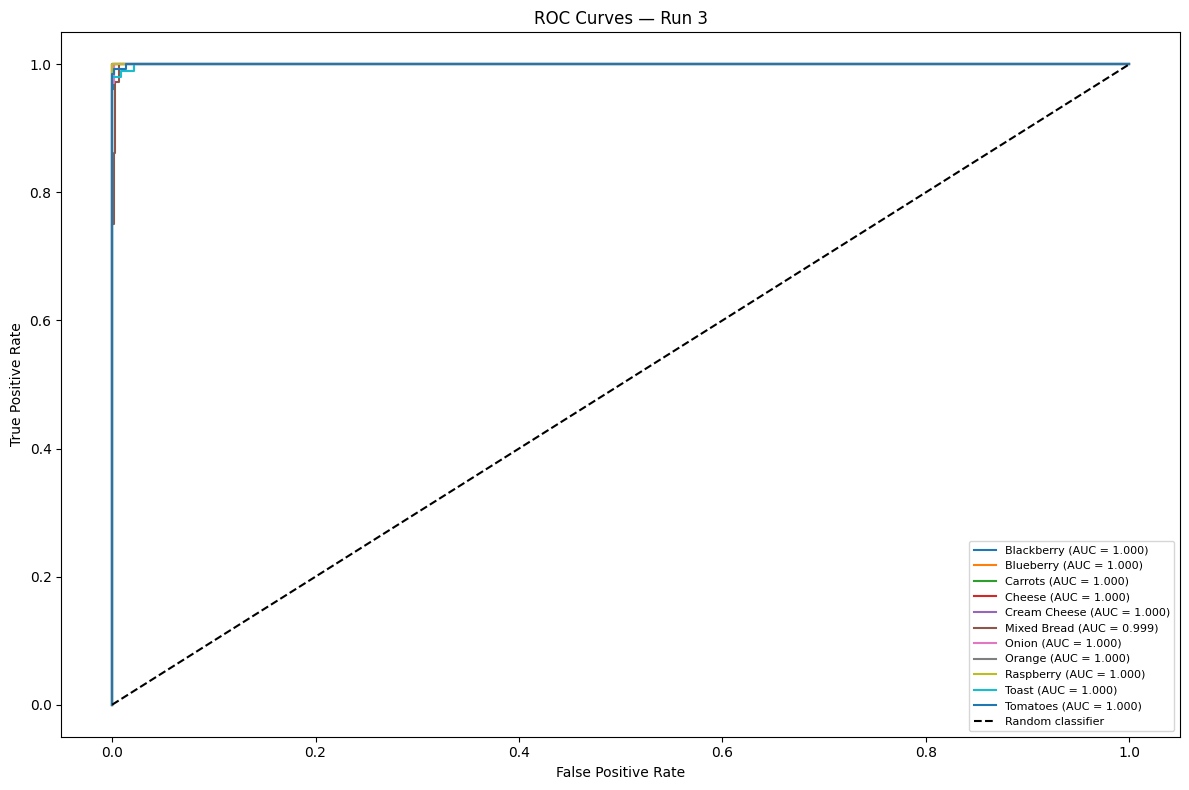

  Saved: D:\Mold Studies\Models\plots\roc_curves_run3.png


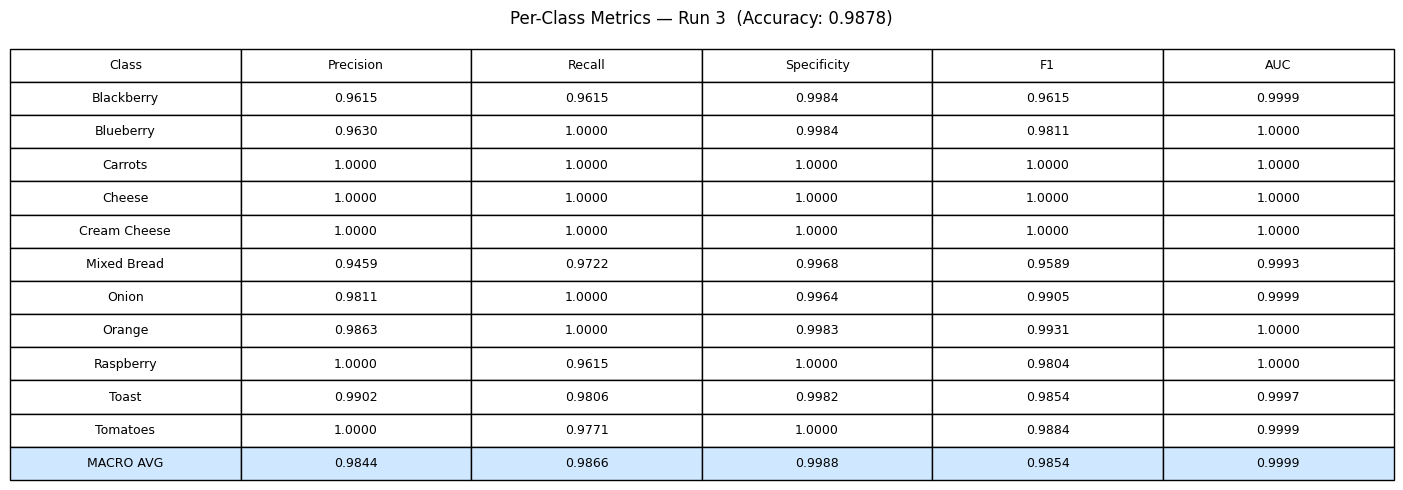

  Saved: D:\Mold Studies\Models\plots\metrics_table_run3.png


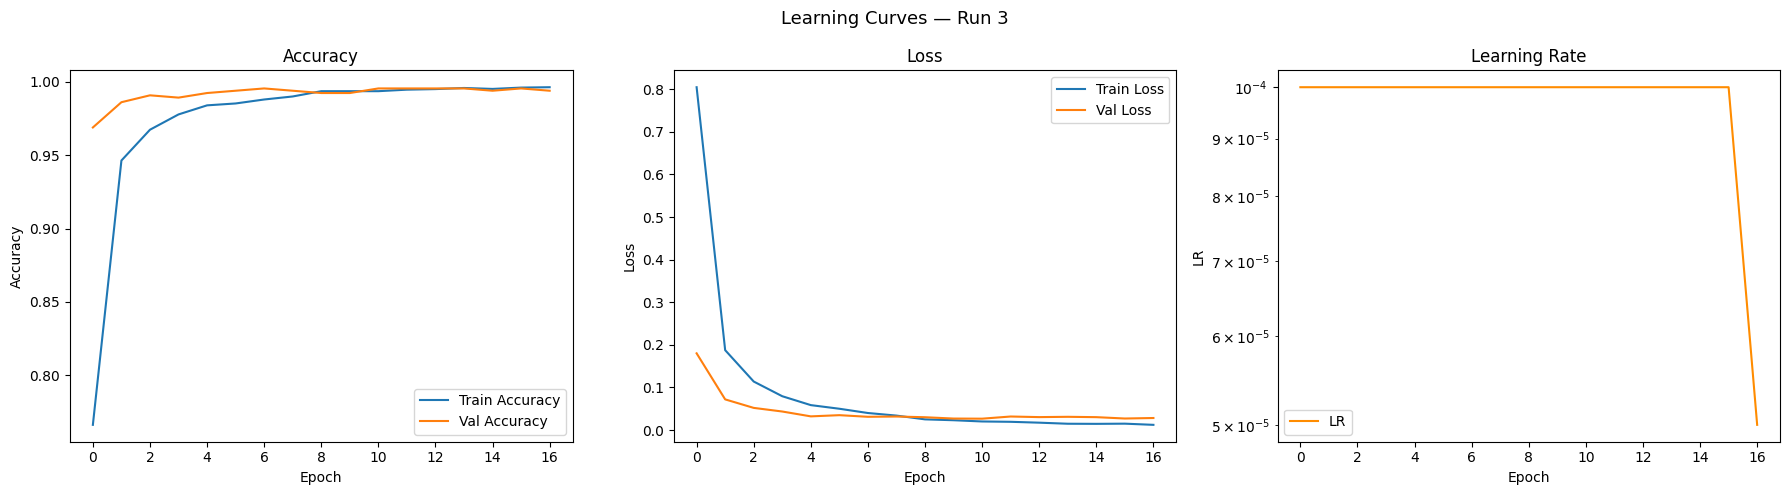

  Saved: D:\Mold Studies\Models\plots\learning_curves_run3.png

  Evaluating Run 4 / 5
  Checkpoint : D:\Mold Studies\Models\mobilenetv2_run4_best.keras
21/21 [==============================] - 3s 106ms/step

  Accuracy     : 0.9878
  Precision    : 0.9850
  Recall       : 0.9874
  Specificity  : 0.9988
  F1 Score     : 0.9860
  Mean AUC     : 0.9999


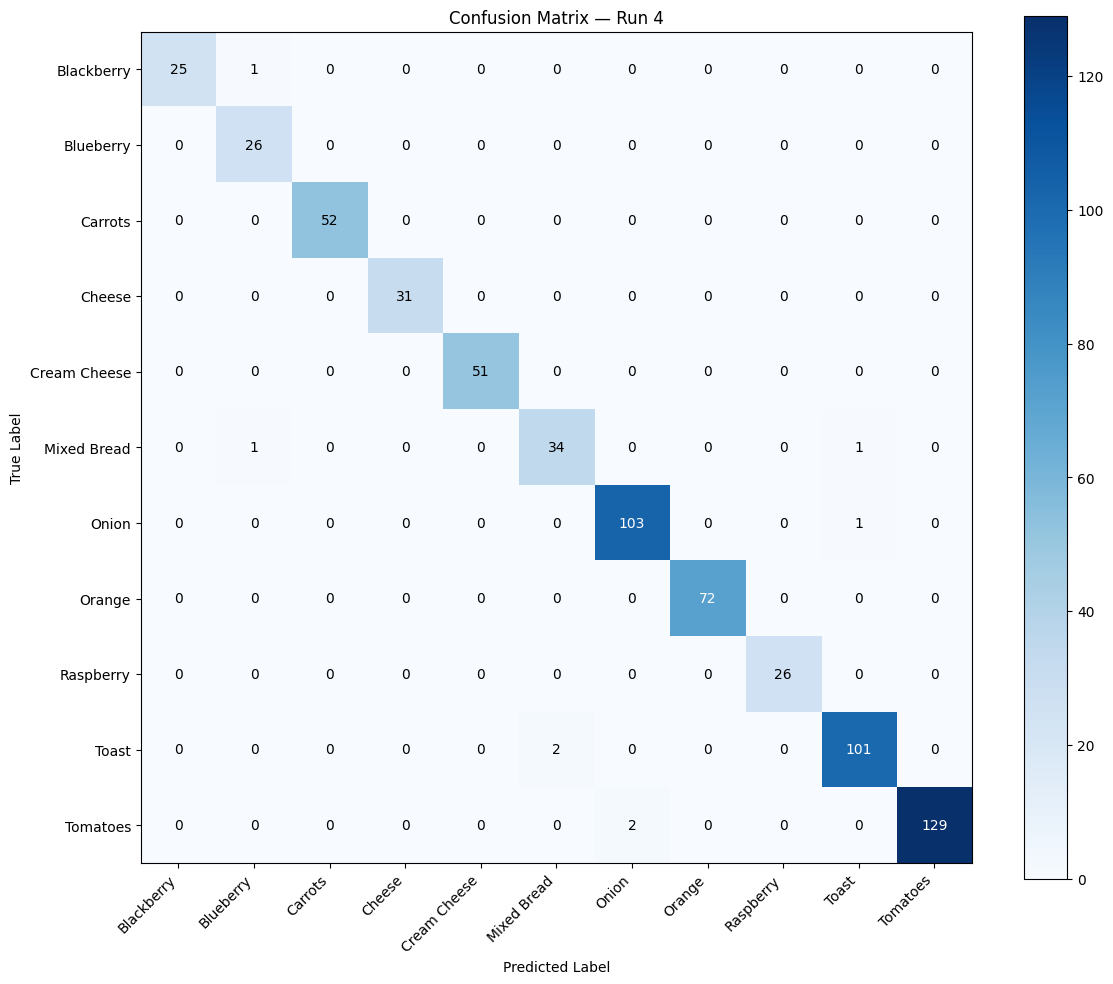

  Saved: D:\Mold Studies\Models\plots\confusion_matrix_run4.png


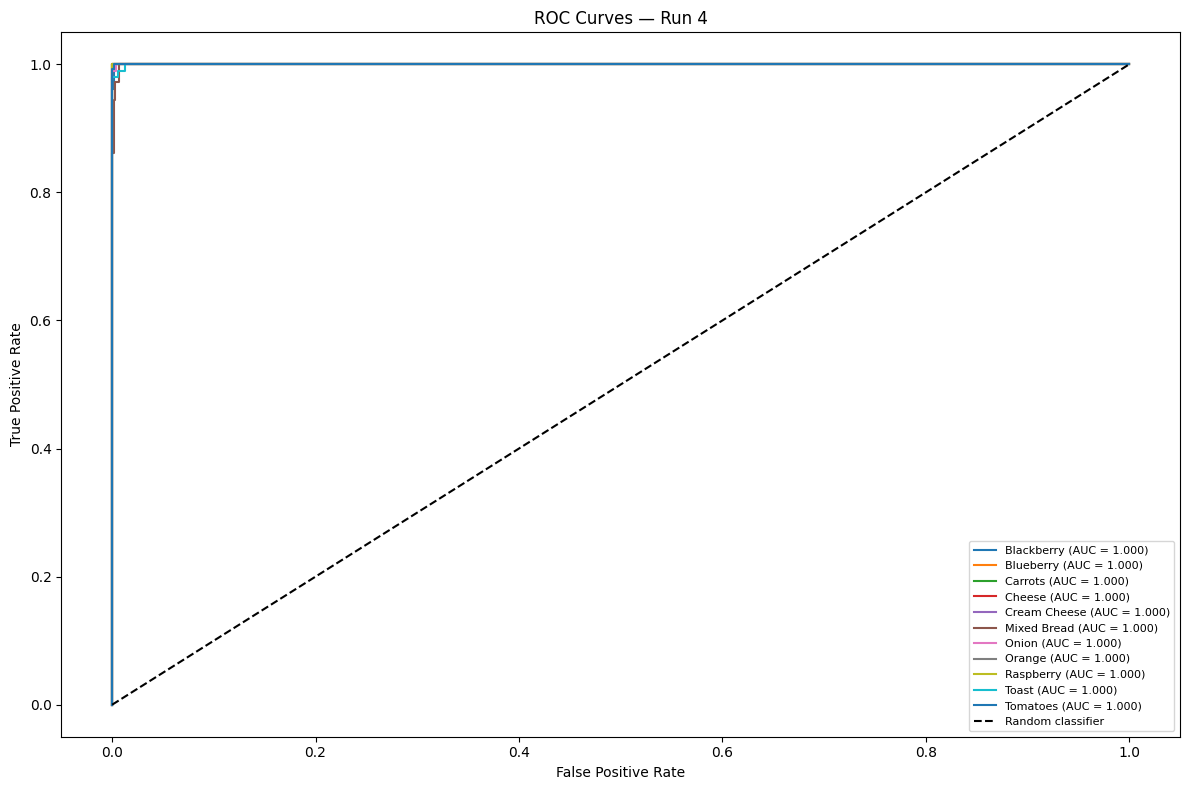

  Saved: D:\Mold Studies\Models\plots\roc_curves_run4.png


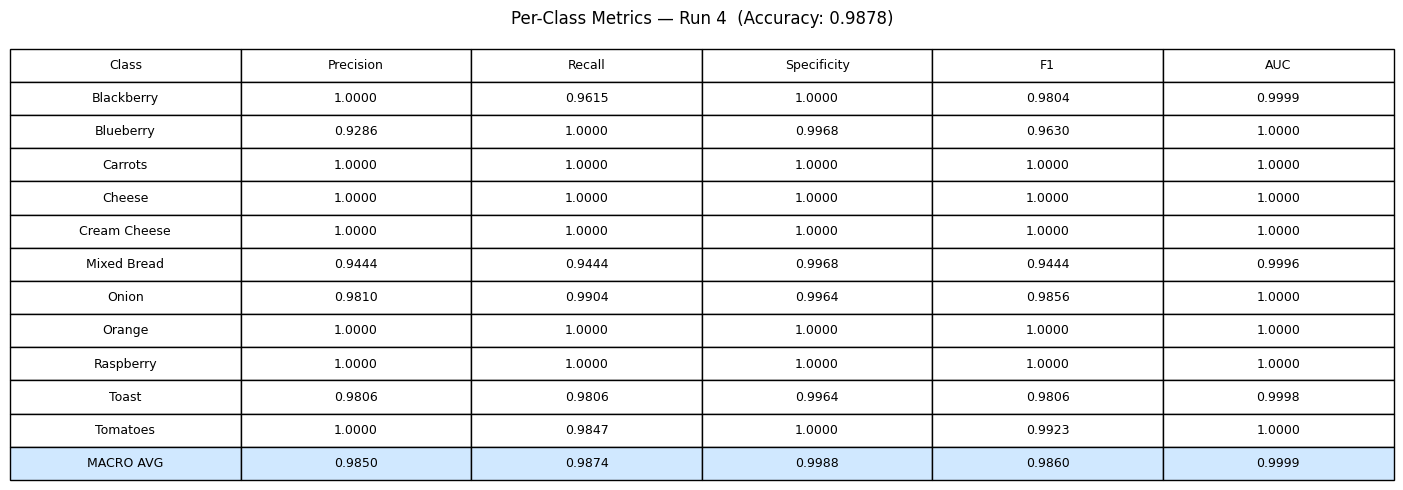

  Saved: D:\Mold Studies\Models\plots\metrics_table_run4.png


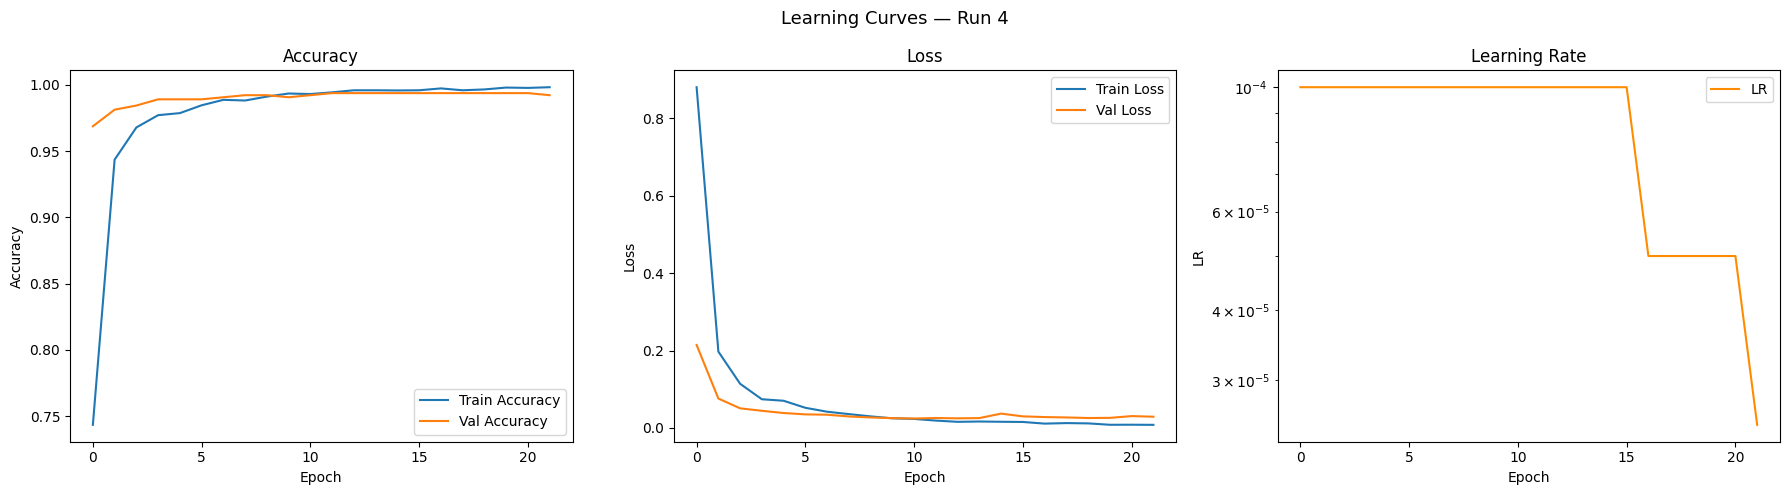

  Saved: D:\Mold Studies\Models\plots\learning_curves_run4.png

  Evaluating Run 5 / 5
  Checkpoint : D:\Mold Studies\Models\mobilenetv2_run5_best.keras
21/21 [==============================] - 3s 104ms/step

  Accuracy     : 0.9878
  Precision    : 0.9846
  Recall       : 0.9876
  Specificity  : 0.9988
  F1 Score     : 0.9859
  Mean AUC     : 0.9999


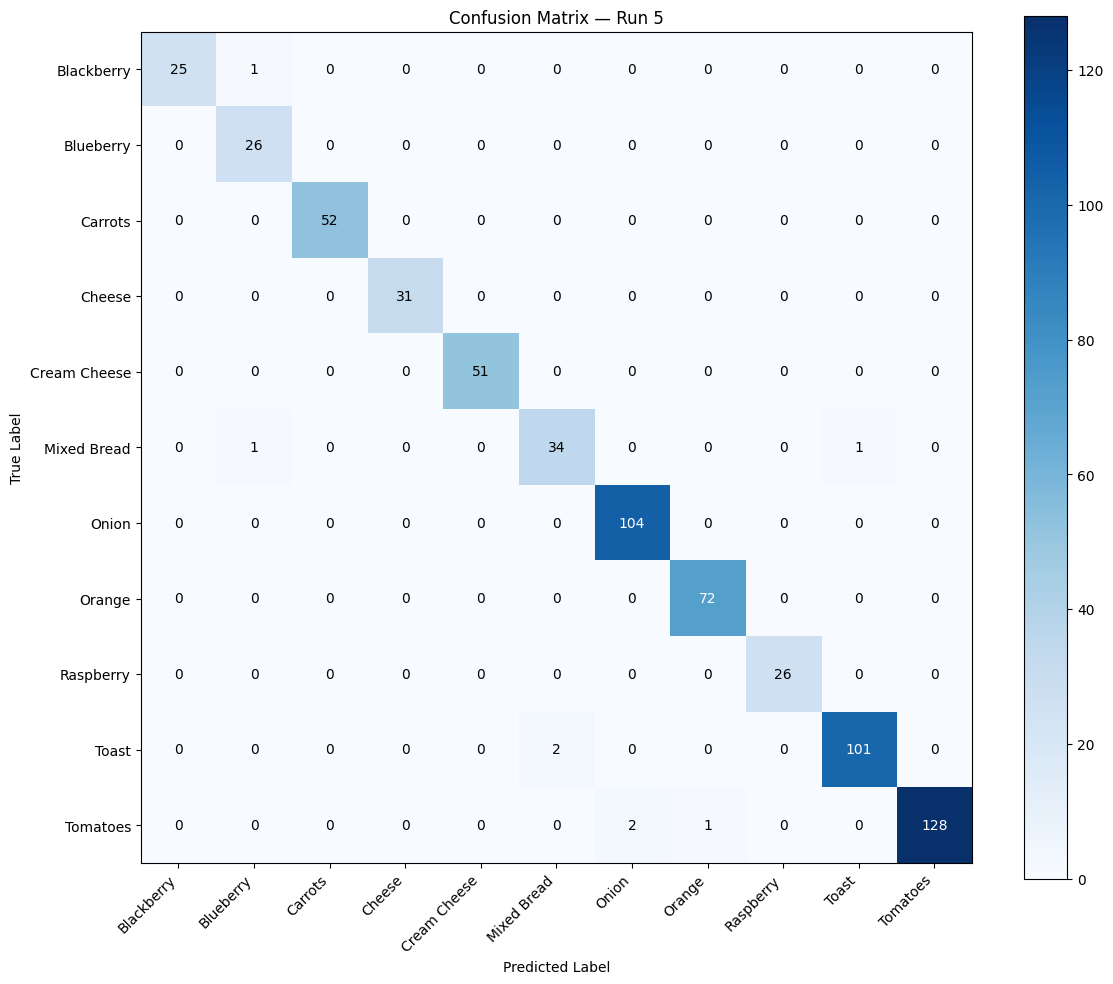

  Saved: D:\Mold Studies\Models\plots\confusion_matrix_run5.png


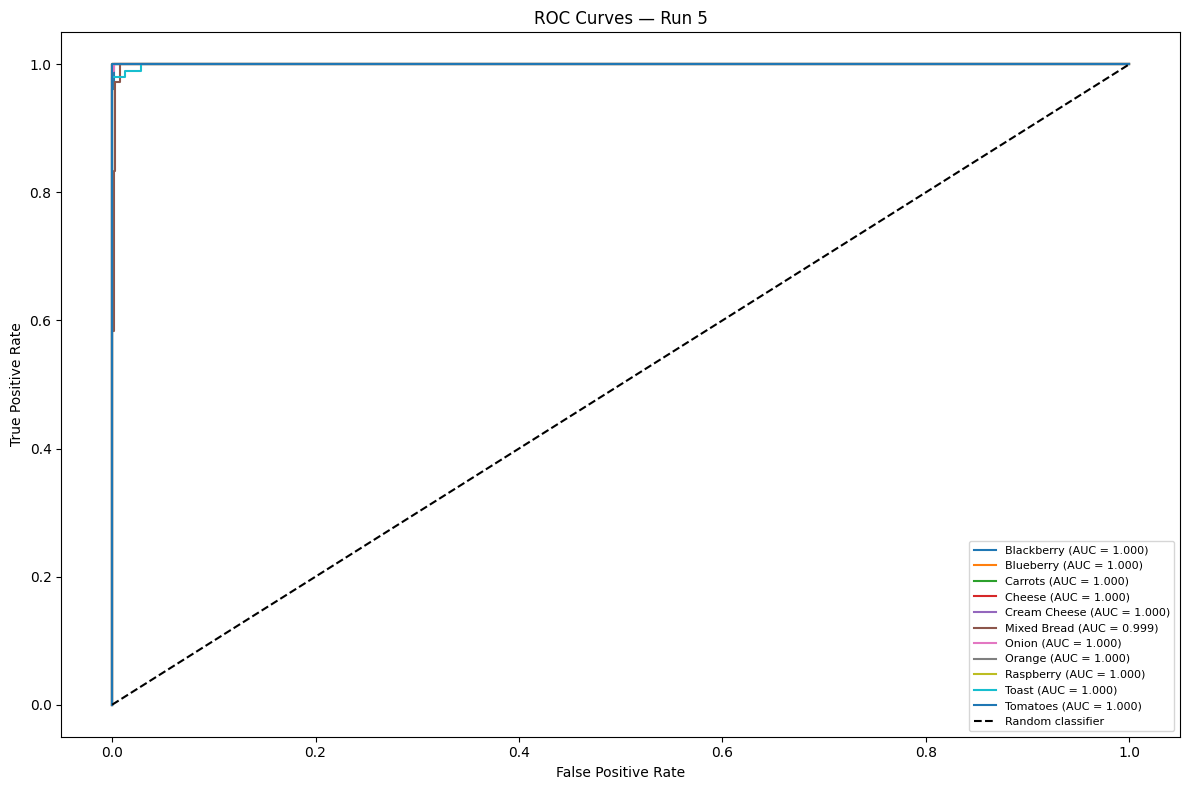

  Saved: D:\Mold Studies\Models\plots\roc_curves_run5.png


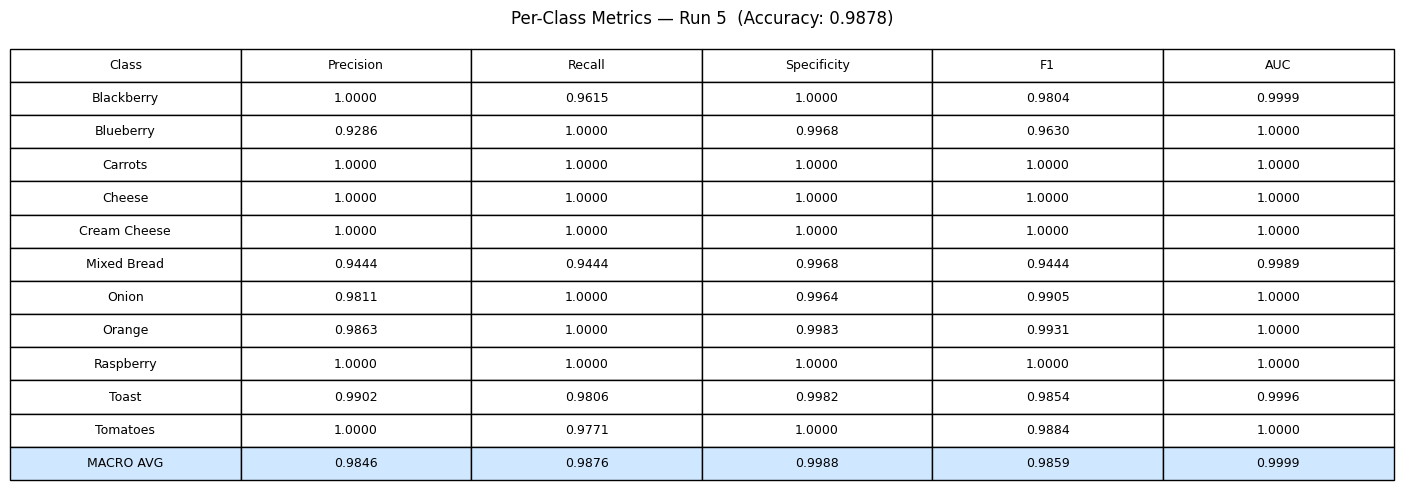

  Saved: D:\Mold Studies\Models\plots\metrics_table_run5.png


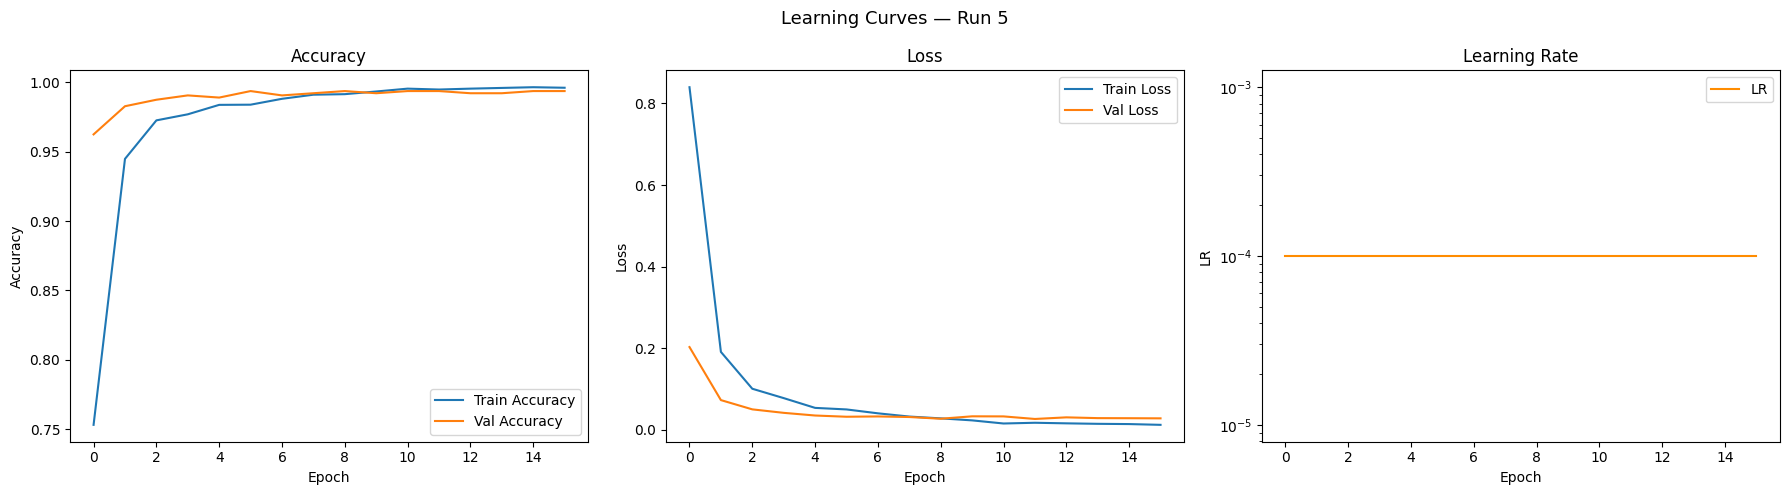

  Saved: D:\Mold Studies\Models\plots\learning_curves_run5.png

  STATISTICAL SUMMARY — All 5 Runs
  Accuracy      : mean=0.9869  std=0.0018  min=0.9833  max=0.9878
  Precision     : mean=0.9845  std=0.0017  min=0.9817  max=0.9869
  Recall        : mean=0.9867  std=0.0013  min=0.9843  max=0.9876
  Specificity   : mean=0.9987  std=0.0002  min=0.9983  max=0.9988
  F1 Score      : mean=0.9855  std=0.0015  min=0.9828  max=0.9871
  AUC           : mean=0.9999  std=0.0000  min=0.9998  max=0.9999

  Best run     : Run 1
  Accuracy     : 0.9878
  F1 Score     : 0.9871
  Mean AUC     : 0.9999

  All plots saved to : D:\Mold Studies\Models\plots

  ✓ Fragment 4 complete.
     Proceed to Fragment 5 — Model Comparison & Reporting.



In [18]:
"""
Fragment 4 — Evaluation & Metrics
===================================
MobileNetV2 Mould/Fruit Multiclass Classification Pipeline

Evaluates all 5 trained runs against the test set.
Metrics computed per run and averaged across all runs:
    - Confusion Matrix
    - Accuracy
    - Precision
    - Recall
    - Specificity
    - F1 Score
    - ROC / AUC (one-vs-rest per class)
    - Learning Rate Curve

TEST DATA — loaded fresh here, never seen during training.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR   = r"D:\Mold Studies\Mould Studies Multiclass"
TEST_DIR   = os.path.join(DATA_DIR, "test")
SAVE_DIR   = r"D:\Mold Studies\Models"
PLOT_DIR   = os.path.join(SAVE_DIR, "plots")

os.makedirs(PLOT_DIR, exist_ok=True)

# ── Step 1: Load Test Generator ───────────────────────────────────────────────

test_datagen = ImageDataGenerator(rescale=1.0 / 255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = "categorical",
    shuffle     = False,       # must be False for correct label alignment
)

CLASS_NAMES = list(test_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("=" * 60)
print("  Step 1 — Test Generator Ready")
print("=" * 60)
print(f"  Test samples : {test_generator.samples}")
print(f"  Classes      : {CLASS_NAMES}")
print("=" * 60)

# ── Step 2: Helper Functions ──────────────────────────────────────────────────

def compute_metrics(y_true, y_pred, y_prob):
    """
    Computes full evaluation metrics from predictions.
    Returns a dictionary of all metrics.
    """
    cm = confusion_matrix(y_true, y_pred)

    # Per-class metrics from confusion matrix
    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - tp - fp - fn

        precision   = tp / (tp + fp + 1e-7)
        recall      = tp / (tp + fn + 1e-7)
        specificity = tn / (tn + fp + 1e-7)
        f1          = 2 * precision * recall / (precision + recall + 1e-7)

        per_class[cls] = {
            "precision"  : precision,
            "recall"     : recall,
            "specificity": specificity,
            "f1"         : f1,
        }

    # Macro averages
    macro_precision   = np.mean([v["precision"]   for v in per_class.values()])
    macro_recall      = np.mean([v["recall"]      for v in per_class.values()])
    macro_specificity = np.mean([v["specificity"] for v in per_class.values()])
    macro_f1          = np.mean([v["f1"]          for v in per_class.values()])
    accuracy          = np.sum(y_true == y_pred) / len(y_true)

    # ROC / AUC — one-vs-rest per class
    y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    roc_auc    = {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[cls] = {
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc(fpr, tpr)
        }

    return {
        "cm"               : cm,
        "per_class"        : per_class,
        "accuracy"         : accuracy,
        "macro_precision"  : macro_precision,
        "macro_recall"     : macro_recall,
        "macro_specificity": macro_specificity,
        "macro_f1"         : macro_f1,
        "roc_auc"          : roc_auc,
    }


def plot_confusion_matrix(cm, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set(
        xticks     = np.arange(NUM_CLASSES),
        yticks     = np.arange(NUM_CLASSES),
        xticklabels= CLASS_NAMES,
        yticklabels= CLASS_NAMES,
        title      = f"Confusion Matrix — Run {run_idx}",
        ylabel     = "True Label",
        xlabel     = "Predicted Label",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    # Annotate cells
    thresh = cm.max() / 2.0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    path = os.path.join(save_dir, f"confusion_matrix_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_roc_curves(roc_auc, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(12, 8))

    for cls in CLASS_NAMES:
        ax.plot(
            roc_auc[cls]["fpr"],
            roc_auc[cls]["tpr"],
            label=f"{cls} (AUC = {roc_auc[cls]['auc']:.3f})"
        )

    ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
    ax.set(
        title  = f"ROC Curves — Run {run_idx}",
        xlabel = "False Positive Rate",
        ylabel = "True Positive Rate",
    )
    ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    path = os.path.join(save_dir, f"roc_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")


def plot_metrics_table(metrics, run_idx, save_dir):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.axis("off")

    rows = []
    for cls in CLASS_NAMES:
        pc = metrics["per_class"][cls]
        rows.append([
            cls,
            f"{pc['precision']:.4f}",
            f"{pc['recall']:.4f}",
            f"{pc['specificity']:.4f}",
            f"{pc['f1']:.4f}",
            f"{metrics['roc_auc'][cls]['auc']:.4f}",
        ])

    # Macro average row
    rows.append([
        "MACRO AVG",
        f"{metrics['macro_precision']:.4f}",
        f"{metrics['macro_recall']:.4f}",
        f"{metrics['macro_specificity']:.4f}",
        f"{metrics['macro_f1']:.4f}",
        f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}",
    ])

    col_labels = ["Class", "Precision", "Recall",
                  "Specificity", "F1", "AUC"]

    table = ax.table(
        cellText    = rows,
        colLabels   = col_labels,
        loc         = "center",
        cellLoc     = "center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.8)

    # Highlight macro row
    for j in range(len(col_labels)):
        table[len(rows), j].set_facecolor("#d0e8ff")

    ax.set_title(f"Per-Class Metrics — Run {run_idx}  "
                 f"(Accuracy: {metrics['accuracy']:.4f})",
                 fontsize=12, pad=20)

    plt.tight_layout()
    path = os.path.join(save_dir, f"metrics_table_run{run_idx}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {path}")


def plot_learning_curves(csv_path, run_idx, save_dir):
    import pandas as pd

    if not os.path.exists(csv_path):
        print(f"  ⚠️  CSV log not found for Run {run_idx}: {csv_path}")
        return

    log = pd.read_csv(csv_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Learning Curves — Run {run_idx}", fontsize=13)

    # Accuracy
    axes[0].plot(log["epoch"], log["accuracy"],     label="Train Accuracy")
    axes[0].plot(log["epoch"], log["val_accuracy"], label="Val Accuracy")
    axes[0].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(log["epoch"], log["loss"],     label="Train Loss")
    axes[1].plot(log["epoch"], log["val_loss"], label="Val Loss")
    axes[1].set(title="Loss", xlabel="Epoch", ylabel="Loss")
    axes[1].legend()

    # Learning Rate
    if "lr" in log.columns:
        axes[2].plot(log["epoch"], log["lr"], color="darkorange", label="LR")
        axes[2].set(title="Learning Rate", xlabel="Epoch", ylabel="LR")
        axes[2].set_yscale("log")
        axes[2].legend()
    else:
        axes[2].text(0.5, 0.5, "LR not logged",
                     ha="center", va="center", transform=axes[2].transAxes)
        axes[2].set_title("Learning Rate")

    plt.tight_layout()
    path = os.path.join(save_dir, f"learning_curves_run{run_idx}.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"  Saved: {path}")

# ── Step 3: Evaluate All 5 Runs ───────────────────────────────────────────────

all_metrics = []

for r in all_run_results:
    run_idx  = r["run"]
    ckpt     = os.path.join(SAVE_DIR, r["checkpoint"])
    csv_path = os.path.join(SAVE_DIR, f"mobilenetv2_run{run_idx}_log.csv")

    print(f"\n{'='*60}")
    print(f"  Evaluating Run {run_idx} / {TOTAL_RUNS}")
    print(f"  Checkpoint : {ckpt}")
    print(f"{'='*60}")

    # Load model
    run_model = tf.keras.models.load_model(ckpt)

    # Reset generator
    test_generator.reset()

    # Predict
    y_prob = run_model.predict(
        test_generator,
        steps   = np.ceil(test_generator.samples / BATCH_SIZE),
        verbose = 1,
    )
    y_pred  = np.argmax(y_prob, axis=1)
    y_true  = test_generator.classes

    # Compute metrics
    metrics = compute_metrics(y_true, y_pred, y_prob)
    metrics["run"] = run_idx
    all_metrics.append(metrics)

    # Print summary
    print(f"\n  Accuracy     : {metrics['accuracy']:.4f}")
    print(f"  Precision    : {metrics['macro_precision']:.4f}")
    print(f"  Recall       : {metrics['macro_recall']:.4f}")
    print(f"  Specificity  : {metrics['macro_specificity']:.4f}")
    print(f"  F1 Score     : {metrics['macro_f1']:.4f}")
    print(f"  Mean AUC     : "
          f"{np.mean([metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

    # Plots
    plot_confusion_matrix(metrics["cm"],       run_idx, PLOT_DIR)
    plot_roc_curves(metrics["roc_auc"],        run_idx, PLOT_DIR)
    plot_metrics_table(metrics,                run_idx, PLOT_DIR)
    plot_learning_curves(csv_path,             run_idx, PLOT_DIR)

# ── Step 4: Statistical Summary Across All 5 Runs ────────────────────────────

print(f"\n{'='*60}")
print(f"  STATISTICAL SUMMARY — All {TOTAL_RUNS} Runs")
print(f"{'='*60}")

metric_keys = {
    "Accuracy"   : "accuracy",
    "Precision"  : "macro_precision",
    "Recall"     : "macro_recall",
    "Specificity": "macro_specificity",
    "F1 Score"   : "macro_f1",
}

for label, key in metric_keys.items():
    vals = [m[key] for m in all_metrics]
    print(f"  {label:<14}: "
          f"mean={np.mean(vals):.4f}  "
          f"std={np.std(vals):.4f}  "
          f"min={np.min(vals):.4f}  "
          f"max={np.max(vals):.4f}")

# Mean AUC across runs
mean_aucs = [
    np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
    for m in all_metrics
]
print(f"  {'AUC':<14}: "
      f"mean={np.mean(mean_aucs):.4f}  "
      f"std={np.std(mean_aucs):.4f}  "
      f"min={np.min(mean_aucs):.4f}  "
      f"max={np.max(mean_aucs):.4f}")

print(f"{'='*60}")

# ── Step 5: Best Run ──────────────────────────────────────────────────────────

best_metrics = max(all_metrics, key=lambda x: x["accuracy"])
print(f"\n  Best run     : Run {best_metrics['run']}")
print(f"  Accuracy     : {best_metrics['accuracy']:.4f}")
print(f"  F1 Score     : {best_metrics['macro_f1']:.4f}")
print(f"  Mean AUC     : "
      f"{np.mean([best_metrics['roc_auc'][c]['auc'] for c in CLASS_NAMES]):.4f}")

print(f"\n  All plots saved to : {PLOT_DIR}")
print(f"\n  ✓ Fragment 4 complete.")
print(f"     Proceed to Fragment 5 — Model Comparison & Reporting.\n")

In [19]:
"""
Summary Table — Best Results Across All 5 Runs
================================================
Prints a single consolidated table showing the best run's
validation accuracy alongside all test set metrics.
"""

import numpy as np

# ── Find Best Run by Validation Accuracy ─────────────────────────────────────

best_run_result  = max(all_run_results, key=lambda x: x["best_val_acc"])
best_run_idx     = best_run_result["run"]
best_run_metrics = next(m for m in all_metrics if m["run"] == best_run_idx)

# ── Mean AUC for best run ─────────────────────────────────────────────────────

best_run_auc_per_class = {
    cls: best_run_metrics["roc_auc"][cls]["auc"]
    for cls in CLASS_NAMES
}
best_run_mean_auc = np.mean(list(best_run_auc_per_class.values()))

# ── Header ────────────────────────────────────────────────────────────────────

col1  = 22   # class name
col2  = 10   # val acc
col3  = 10   # test acc
col4  = 12   # precision
col5  = 10   # recall
col6  = 13   # specificity
col7  = 10   # f1
col8  = 10   # auc

divider = "=" * (col1 + col2 + col3 + col4 + col5 + col6 + col7 + col8 + 9)
thin    = "─" * (col1 + col2 + col3 + col4 + col5 + col6 + col7 + col8 + 9)

print(divider)
print(f"  BEST RUN SUMMARY — Run {best_run_idx}  "
      f"(selected by highest validation accuracy)")
print(divider)
print(
    f"  {'Class':<{col1}}"
    f"{'Val Acc':>{col2}}"
    f"{'Test Acc':>{col3}}"
    f"{'Precision':>{col4}}"
    f"{'Recall':>{col5}}"
    f"{'Specificity':>{col6}}"
    f"{'F1':>{col7}}"
    f"{'AUC':>{col8}}"
)
print(thin)

# ── Per-Class Rows ────────────────────────────────────────────────────────────

for cls in CLASS_NAMES:
    pc        = best_run_metrics["per_class"][cls]
    cls_auc   = best_run_auc_per_class[cls]

    # Val accuracy is model-level (not per class) — shown only on first row
    val_acc_display = f"{best_run_result['best_val_acc']:.4f}" \
                      if cls == CLASS_NAMES[0] else "—"

    # Test accuracy is model-level — shown only on first row
    test_acc_display = f"{best_run_metrics['accuracy']:.4f}" \
                       if cls == CLASS_NAMES[0] else "—"

    print(
        f"  {cls:<{col1}}"
        f"{val_acc_display:>{col2}}"
        f"{test_acc_display:>{col3}}"
        f"{pc['precision']:>{col4}.4f}"
        f"{pc['recall']:>{col5}.4f}"
        f"{pc['specificity']:>{col6}.4f}"
        f"{pc['f1']:>{col7}.4f}"
        f"{cls_auc:>{col8}.4f}"
    )

print(thin)

# ── Macro Average Row ─────────────────────────────────────────────────────────

print(
    f"  {'MACRO AVG':<{col1}}"
    f"{'—':>{col2}}"
    f"{'—':>{col3}}"
    f"{best_run_metrics['macro_precision']:>{col4}.4f}"
    f"{best_run_metrics['macro_recall']:>{col5}.4f}"
    f"{best_run_metrics['macro_specificity']:>{col6}.4f}"
    f"{best_run_metrics['macro_f1']:>{col7}.4f}"
    f"{best_run_mean_auc:>{col8}.4f}"
)

print(thin)

# ── Overall Row ───────────────────────────────────────────────────────────────

print(
    f"  {'OVERALL':<{col1}}"
    f"{best_run_result['best_val_acc']:>{col2}.4f}"
    f"{best_run_metrics['accuracy']:>{col3}.4f}"
    f"{'—':>{col4}}"
    f"{'—':>{col5}}"
    f"{'—':>{col6}}"
    f"{'—':>{col7}}"
    f"{'—':>{col8}}"
)

print(divider)

# ── Statistical Summary Across All 5 Runs ────────────────────────────────────

print(f"\n{'='*60}")
print(f"  STATISTICAL ANALYSIS — All {TOTAL_RUNS} Runs")
print(f"{'='*60}")
print(f"  {'Metric':<16} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print(f"  {'─'*52}")

stat_metrics = {
    "Val Accuracy"  : [r["best_val_acc"]           for r in all_run_results],
    "Test Accuracy" : [m["accuracy"]                for m in all_metrics],
    "Precision"     : [m["macro_precision"]          for m in all_metrics],
    "Recall"        : [m["macro_recall"]             for m in all_metrics],
    "Specificity"   : [m["macro_specificity"]        for m in all_metrics],
    "F1 Score"      : [m["macro_f1"]                for m in all_metrics],
    "AUC"           : [
        np.mean([m["roc_auc"][c]["auc"] for c in CLASS_NAMES])
        for m in all_metrics
    ],
}

for label, vals in stat_metrics.items():
    print(
        f"  {label:<16}"
        f"{np.mean(vals):>8.4f}"
        f"{np.std(vals):>8.4f}"
        f"{np.min(vals):>8.4f}"
        f"{np.max(vals):>8.4f}"
    )

print(f"{'='*60}")
print(f"\n  ✓ Summary table complete.")

  BEST RUN SUMMARY — Run 1  (selected by highest validation accuracy)
  Class                    Val Acc  Test Acc   Precision    Recall  Specificity        F1       AUC
──────────────────────────────────────────────────────────────────────────────────────────────────────────
  Blackberry                0.9953    0.9878      1.0000    0.9615       1.0000    0.9804    0.9999
  Blueberry                      —         —      0.9630    1.0000       0.9984    0.9811    1.0000
  Carrots                        —         —      1.0000    1.0000       1.0000    1.0000    1.0000
  Cheese                         —         —      1.0000    1.0000       1.0000    1.0000    1.0000
  Cream Cheese                   —         —      1.0000    1.0000       1.0000    1.0000    1.0000
  Mixed Bread                    —         —      0.9444    0.9444       0.9968    0.9444    0.9992
  Onion                          —         —      0.9811    1.0000       0.9964    0.9905    1.0000
  Orange               